In [22]:
import textwrap

import faceted
import numpy as np
import wandb
import matplotlib as mpl
import pandas as pd
import xarray as xr

from matplotlib.lines import Line2D

import plotting
import utils

In [23]:
api = wandb.Api()

In [24]:
def wandb_id_from_name(name):
    api = wandb.Api()
    runs = api.runs("ai2cm/ace-shield", filters={"display_name": {"$regex": name}})
    completed = [run for run in runs if run.state == "finished"]
    return completed[-1]

SHIELD_RUNS = {
    f"SHiELD-4xCO2-ic_{ic}": wandb_id_from_name(f"shield-data-only-evaluator-abrupt4xCO2-ic-{ic:04d}") for ic in range(1, 37)
}

In [25]:
Lv = 2.5e6  # J/kg
SECONDS_PER_DAY = 86400

VARIABLE_NAMES = [
    "PRATEsfc",
    "LHTFLsfc",
    "SHTFLsfc",
    "surface_temperature",
    "air_temperature_0",
    "air_temperature_1",
    "air_temperature_2",
    "air_temperature_3",
    "air_temperature_4",
    "air_temperature_5",
    "air_temperature_6",
    "air_temperature_7",
    "ULWRFtoa",
    "net_energy_flux_toa_into_atmosphere",
    "USWRFtoa",
    "DSWRFsfc",
    "USWRFsfc",
    "DLWRFsfc",
    "ULWRFsfc",
    "total_energy_ace2_path",
    "net_energy_flux_sfc_into_atmosphere",
    "net_energy_flux_into_atmospheric_column",
    "implied_tendency_of_total_energy_ace2_path_due_to_advection",
    "total_water_path",
]
METRIC_NAMES = [f"inference/mean/weighted_mean_gen/{var}" for var in VARIABLE_NAMES]
BIAS_NAMES = [f"inference/mean/weighted_bias/{var}" for var in VARIABLE_NAMES]
TARGET_NAMES = [f"inference/mean/weighted_mean_target/{var}" for var in VARIABLE_NAMES]
UNITS = {
    "PRATEsfc": "mm/day",
    "LHTFLsfc": "W/m^2",
    "SHTFLsfc": "W/m^2",
    "surface_temperature": "K",
    "air_temperature_0": "K",
    "air_temperature_1": "K",
    "air_temperature_2": "K",
    "air_temperature_3": "K",
    "air_temperature_4": "K",
    "air_temperature_5": "K",
    "air_temperature_6": "K",
    "air_temperature_7": "K",
    "ULWRFtoa": "W/m^2",
    "net_energy_flux_toa_into_atmosphere": "W/m^2",
    "USWRFtoa": "W/m^2",
    "DSWRFsfc": "W/m^2",
    "USWRFsfc": "W/m^2",
    "DLWRFsfc": "W/m^2",
    "ULWRFsfc": "W/m^2",
    "total_energy_ace2_path": "J/m^2",
    "net_energy_flux_sfc_into_atmosphere": "W/m^2",
    "net_energy_flux_into_atmospheric_column": "W/m^2",
    "implied_tendency_of_total_energy_ace2_path_due_to_advection": "W/m^2",
    "energy budget imbalance\n(energy tendency minus flux into atmos)": "W/m^2",
    "total_water_path": "mm",
    "imposed_heating": "W/m^2",
    "evaporation": "mm/day",
}

In [26]:
TEMPLATE = "2026-09-09-{model}-abrupt-4xCO2-ensemble-evaluator"

# these runs did a 36-member ensemble in a single run so already have
# ensemble-mean statistics
ACE_RUN_IDS = {
    "ACE2-SOM baseline 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="published-baseline-rs3")),
    "no-random-co2 non-energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-rs0")),
    "no-random-co2 non-energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-rs1")),
    "no-random-co2 energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0")),
    "no-random-co2 energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1")),
    "full non-energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-rs0")),
    "full non-energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-rs1")),
    "full energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0")),
    "full energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1")),
}


In [27]:
COLORS = {
    "SHiELD 4xCO2": "k",
    "SHiELD 1xCO2": "k",
    "ACE2-SOM baseline 4xCO2": "C3",
    "no-random-co2 non-energy-conserving rs0 4xCO2": "C1",
    "no-random-co2 non-energy-conserving rs1 4xCO2": "C1",
    "no-random-co2 energy-conserving rs0 4xCO2": "C2",
    "no-random-co2 energy-conserving rs1 4xCO2": "C2",
    "full non-energy-conserving rs0 4xCO2": "C5",
    "full non-energy-conserving rs1 4xCO2": "C5",
    "full energy-conserving rs0 4xCO2": "C4",
    "full energy-conserving rs1 4xCO2": "C4",
}
LINESTYLES = {"SHiELD 1xCO2": "--"}

In [28]:
ACE_RUNS = {}
for name, id in ACE_RUN_IDS.items():
    ACE_RUNS[name] = api.run(id)

In [29]:
def load_metrics_from_wandb(run, keys, offset_time=1):
    history = pd.DataFrame(run.scan_history(keys=keys))
    ds = xr.Dataset.from_dataframe(history)
    ds = ds.rename({"index": "time"})
    ds["time"] = ((ds.time + offset_time) / 4).assign_attrs(units="days since init")
    ds = ds.assign_coords(time=ds.time)
    return ds.rename({s: s.rsplit('/', 1)[-1] for s in ds.data_vars})

In [30]:
# Initialize an empty dictionary to store the data
ds_shield = []

# Loop through each model and case to extract the metric data
for name, run in SHIELD_RUNS.items():
    ds = load_metrics_from_wandb(run, METRIC_NAMES)
    ds = ds.assign_coords(initial_condition=name[-4:])
    ds_shield.append(ds)
ds_shield = xr.concat(ds_shield, dim="ic")
ds_shield["PRATEsfc"] = (ds_shield["PRATEsfc"] * SECONDS_PER_DAY).assign_attrs(units="mm/day")
ds_shield_mean = ds_shield.mean("ic")

In [31]:
ds_ace_4xCO2 = []

for name, run in ACE_RUNS.items():
    ds = load_metrics_from_wandb(run, METRIC_NAMES)
    ds = ds.assign_coords(model=name)
    ds_ace_4xCO2.append(ds)
ds_ace_4xCO2 = xr.concat(ds_ace_4xCO2, dim="model")
ds_ace_4xCO2["PRATEsfc"] = (ds_ace_4xCO2["PRATEsfc"] * SECONDS_PER_DAY).assign_attrs(units="mm/day")

run = ACE_RUNS["no-random-co2 non-energy-conserving rs0 4xCO2"]
ds_shield_1xCO2 = load_metrics_from_wandb(run, TARGET_NAMES)
ds_shield_1xCO2 = ds_shield_1xCO2.assign_coords(model="SHiELD 1xCO2")
ds_shield_1xCO2["PRATEsfc"] = (ds_shield_1xCO2["PRATEsfc"] * SECONDS_PER_DAY).assign_attrs(units="mm/day")

In [32]:
ds = xr.concat(
    [
        ds_shield_1xCO2,
        ds_shield_mean.assign_coords(model='SHiELD 4xCO2'),
        ds_ace_4xCO2,
    ],
    dim="model",
    join='inner'
)
ds['evaporation'] = ds['LHTFLsfc'] / Lv * SECONDS_PER_DAY

for name in ds:
    if name in UNITS:
        ds[name].attrs['units'] = UNITS[name]


ds["frozen_precipitation_energy_flux"] = (
    ds.net_energy_flux_sfc_into_atmosphere
    + ds.DLWRFsfc
    + ds.DSWRFsfc
    - ds.ULWRFsfc
    - ds.USWRFsfc
    - ds.LHTFLsfc
    - ds.SHTFLsfc
)
ds_daily = ds.coarsen(time=4, boundary="trim").mean()

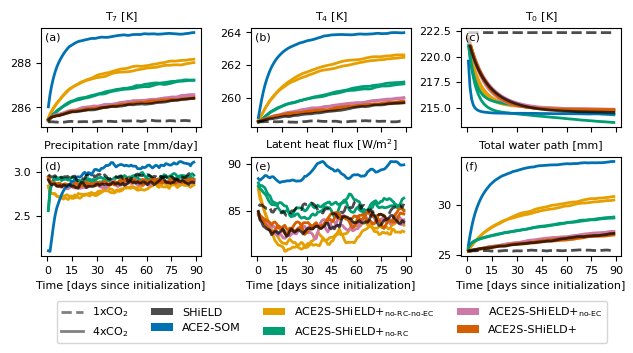

In [35]:
plotting.configure_style()

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = faceted.faceted(2, 3, width=6.5, sharey=False, internal_pad=(0.5, 0.3), left_pad=0.4, bottom_pad=0.9, right_pad=0.3, top_pad=0.25)
for model in ds_daily.model:
    ls = "-" if "4xCO2" in model.item() else "--"
    zorder = 0 if "SHiELD" not in model.item() else 10
    alpha = 1.0 if "SHiELD" not in model.item() else 0.7
    if "baseline" in model.item():
        zorder = 5
        lw = 2
    else:
        lw = 2
    ds_daily.sel(model=model).air_temperature_7.plot(ax=ax1, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).air_temperature_4.plot(ax=ax2, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).air_temperature_0.plot(ax=ax3, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)

    ds_daily.sel(model=model).PRATEsfc.plot(ax=ax4, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).LHTFLsfc.plot(ax=ax5, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).total_water_path.plot(ax=ax6, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)

ax1.set_title(textwrap.fill("T$_7$ [K]", width=30))
ax2.set_title(textwrap.fill("T$_4$ [K]", width=30))
ax3.set_title(textwrap.fill("T$_0$ [K]", width=30))

ax4.set_title(textwrap.fill("Precipitation rate [mm/day]", width=30))
ax5.set_title(textwrap.fill("Latent heat flux [W/m$^2$]", width=30))
ax6.set_title(textwrap.fill("Total water path [mm]", width=30))

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in (ax4, ax5, ax6):
    ax.set_xlabel("Time [days since initialization]")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(0, 91, 15))

line_data = {
    "1xCO$_2$": ("gray", "--"),
    "4xCO$_2$": ("gray", "-"),
}
lines = [Line2D([0], [0], color=color, linestyle=ls, lw=2) for color, ls in line_data.values()]
patch_colors = {
    "SHiELD": ("k", 0.7),
    "ACE2-SOM": ("C3", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC-no-EC}}$": ("C1", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC}}$": ("C2", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-EC}}$": ("C5", 1.0),
    "ACE2S-SHiELD+": ("C4", 1.0),
}

from matplotlib.patches import Patch

patches = [
    Patch(facecolor=color, label=label, edgecolor='none', alpha=alpha)
    for label, (color, alpha) in patch_colors.items()
]

ax5.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), bbox_to_anchor=(-1.25, -0.4), bbox_transform=ax5.transAxes, loc="upper left", ncol=4, fontsize=8)

for ax, label in zip((ax1, ax2, ax3, ax4, ax5, ax6), ("a", "b", "c", "d", "e", "f")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(3, -3),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        zorder=100,
    )

fig.patch.set_alpha(0.0)
fig.savefig("figure-08-all-seeds.png", dpi=300)
fig.savefig("figure-08-all-seeds.pdf")


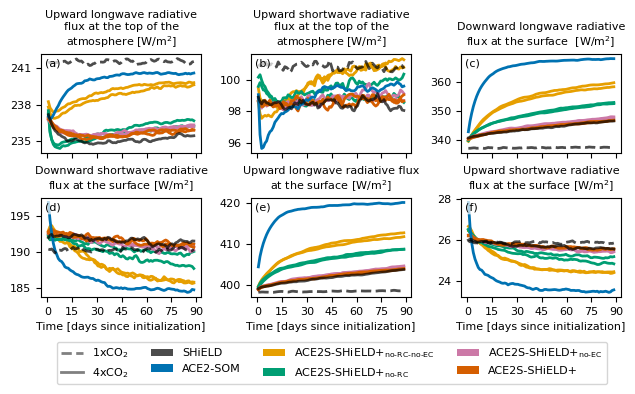

In [36]:
plotting.configure_style()

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = faceted.faceted(2, 3, width=6.5, sharey=False, internal_pad=(0.5, 0.45), left_pad=0.4, bottom_pad=0.9, right_pad=0.3, top_pad=0.5)
for model in ds_daily.model:
    ls = "-" if "4xCO2" in model.item() else "--"
    zorder = 0 if "SHiELD" not in model.item() else 10
    alpha = 1.0 if "SHiELD" not in model.item() else 0.7
    if "baseline" in model.item():
        zorder = 5
        lw = 2
    else:
        lw = 2
    ds_daily.sel(model=model).ULWRFtoa.plot(ax=ax1, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).USWRFtoa.plot(ax=ax2, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).DLWRFsfc.plot(ax=ax3, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).DSWRFsfc.plot(ax=ax4, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).ULWRFsfc.plot(ax=ax5, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).USWRFsfc.plot(ax=ax6, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)

ax1.set_title(textwrap.fill("Upward longwave radiative flux at the top of the atmosphere [W/m$^2$]", width=29))
ax2.set_title(textwrap.fill("Upward shortwave radiative flux at the top of the atmosphere [W/m$^2$]", width=30))
ax3.set_title(textwrap.fill("Downward longwave radiative flux at the surface  [W/m$^2$]", width=30))

ax4.set_title(textwrap.fill("Downward shortwave radiative flux at the surface [W/m$^2$]", width=30))
ax5.set_title(textwrap.fill("Upward longwave radiative flux at the surface [W/m$^2$]", width=30))
ax6.set_title(textwrap.fill("Upward shortwave radiative flux at the surface [W/m$^2$]", width=30))

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in (ax4, ax5, ax6):
    ax.set_xlabel("Time [days since initialization]")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(0, 91, 15))

line_data = {
    "1xCO$_2$": ("gray", "--"),
    "4xCO$_2$": ("gray", "-"),
}
lines = [Line2D([0], [0], color=color, linestyle=ls, lw=2) for color, ls in line_data.values()]
patch_colors = {
    "SHiELD": ("k", 0.7),
    "ACE2-SOM": ("C3", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC-no-EC}}$": ("C1", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC}}$": ("C2", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-EC}}$": ("C5", 1.0),
    "ACE2S-SHiELD+": ("C4", 1.0),
}

from matplotlib.patches import Patch

patches = [
    Patch(facecolor=color, label=label, edgecolor='none', alpha=alpha)
    for label, (color, alpha) in patch_colors.items()
]

ax5.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), bbox_to_anchor=(-1.25, -0.4), bbox_transform=ax5.transAxes, loc="upper left", ncol=4, fontsize=8)

for ax, label in zip((ax1, ax2, ax3, ax4, ax5, ax6), ("a", "b", "c", "d", "e", "f")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(3, -3),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        zorder=100,
    )

ax1.set_yticks([235, 238, 241])

fig.patch.set_alpha(0.0)
fig.savefig("figure-10-all-seeds.png", dpi=300)
fig.savefig("figure-10-all-seeds.pdf")